In [3]:
!pip show datasets

Name: datasets
Version: 2.21.0
Summary: HuggingFace community-driven open-source library of datasets
Home-page: https://github.com/huggingface/datasets
Author: HuggingFace Inc.
Author-email: thomas@huggingface.co
License: Apache 2.0
Location: /opt/miniconda3/envs/langchain/lib/python3.11/site-packages
Requires: aiohttp, dill, filelock, fsspec, huggingface-hub, multiprocess, numpy, packaging, pandas, pyarrow, pyyaml, requests, tqdm, xxhash
Required-by: ragas


In [4]:
!(pwd)

/Users/hgkahng/Workspaces/soft-prompt/notebooks/emotion


In [ ]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tiktoken

from sklearn.model_selection import train_test_split
from datasets import load_dataset

# 1. Load data

## 1-1. Split
- train, validation, test

In [6]:
ds = load_dataset("dair-ai/emotion", "split", cache_dir="../../.cache/")

In [7]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [8]:
df_train = pd.DataFrame(ds['train'])
df_train

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3
...,...,...
15995,i just had a very brief time in the beanbag an...,0
15996,i am now turning and i feel pathetic that i am...,0
15997,i feel strong and good overall,1
15998,i feel like this was such a rude comment and i...,3


In [9]:
df_val = pd.DataFrame(ds['validation'])
df_val

,text,label
0,im feeling quite sad and sorry for myself but ...,0
1,i feel like i am still looking at a blank canv...,0
2,i feel like a faithful servant,2
3,i am just feeling cranky and blue,3
4,i can have for a treat or if i am feeling festive,1
...,...,...
1995,im having ssa examination tomorrow in the morn...,0
1996,i constantly worry about their fight against n...,1
1997,i feel its important to share this info for th...,1
1998,i truly feel that if you are passionate enough...,1


In [10]:
df_test = pd.DataFrame(ds['test'])
df_test

,text,label
0,im feeling rather rotten so im not very ambiti...,0
1,im updating my blog because i feel shitty,0
2,i never make her separate from me because i do...,0
3,i left with my bouquet of red and yellow tulip...,1
4,i was feeling a little vain when i did this one,0
...,...,...
1995,i just keep feeling like someone is being unki...,3
1996,im feeling a little cranky negative after this...,3
1997,i feel that i am useful to my people and that ...,1
1998,im feeling more comfortable with derby i feel ...,1


## 1-2. Unsplit

In [14]:
ds_unsplit = load_dataset("dair-ai/emotion", "unsplit", cache_dir="../../.cache/")
ds_unsplit

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 416809
    })
})

In [15]:
df_unsplit = pd.DataFrame(ds_unsplit['train'])
df_unsplit

,text,label
0,i feel awful about it too because it s my job ...,0
1,im alone i feel awful,0
2,ive probably mentioned this before but i reall...,1
3,i was feeling a little low few days back,0
4,i beleive that i am much more sensitive to oth...,2
...,...,...
416804,that was what i felt when i was finally accept...,1
416805,i take every day as it comes i m just focussin...,4
416806,i just suddenly feel that everything was fake,0
416807,im feeling more eager than ever to claw back w...,1


In [18]:
df_unsplit['label'].value_counts(normalize=True)

label
1    0.338445
0    0.290749
3    0.137514
4    0.114470
2    0.082901
5    0.035921
Name: proportion, dtype: float64

# 2. Data Statistics

Label Distribution

In [29]:
df_train['label'].value_counts(normalize=True)

label
1    0.335125
0    0.291625
3    0.134937
4    0.121063
2    0.081500
5    0.035750
Name: proportion, dtype: float64

In [30]:
df_val['label'].value_counts(normalize=True)

label
1    0.3520
0    0.2750
3    0.1375
4    0.1060
2    0.0890
5    0.0405
Name: proportion, dtype: float64

In [31]:
df_test['label'].value_counts(normalize=True)

label
1    0.3475
0    0.2905
3    0.1375
4    0.1120
2    0.0795
5    0.0330
Name: proportion, dtype: float64

In [32]:
df_unsplit['label'].value_counts(normalize=True)

label
1    0.338445
0    0.290749
3    0.137514
4    0.114470
2    0.082901
5    0.035921
Name: proportion, dtype: float64

Length

In [34]:
encoding = tiktoken.encoding_for_model("gpt-4o")  # import tiktoken

In [35]:
df_train['num_tokens'] = [len(r) for r in encoding.encode_batch(df_train['text'])]
df_val['num_tokens'] = [len(r) for r in encoding.encode_batch(df_val['text'])]
df_test['num_tokens'] = [len(r) for r in encoding.encode_batch(df_test['text'])]
df_unsplit['num_tokens'] = [len(r) for r in encoding.encode_batch(df_unsplit['text'])]

In [36]:
df_train['split'] = 'train'
df_val['split'] = 'validation'
df_test['split'] = 'test'
df_unsplit['split'] = 'unsplit'

df_all = pd.concat([df_train, df_val, df_test, df_unsplit], axis=0, ignore_index=True)

from IPython.display import display
display(df_all);

,text,label,num_tokens,split
0,i didnt feel humiliated,0,5,train
1,i can go from feeling so hopeless to so damned...,0,21,train
2,im grabbing a minute to post i feel greedy wrong,3,10,train
3,i am ever feeling nostalgic about the fireplac...,2,18,train
4,i am feeling grouchy,3,5,train
...,...,...,...,...
436804,that was what i felt when i was finally accept...,1,26,unsplit
436805,i take every day as it comes i m just focussin...,4,40,unsplit
436806,i just suddenly feel that everything was fake,0,8,unsplit
436807,im feeling more eager than ever to claw back w...,1,20,unsplit


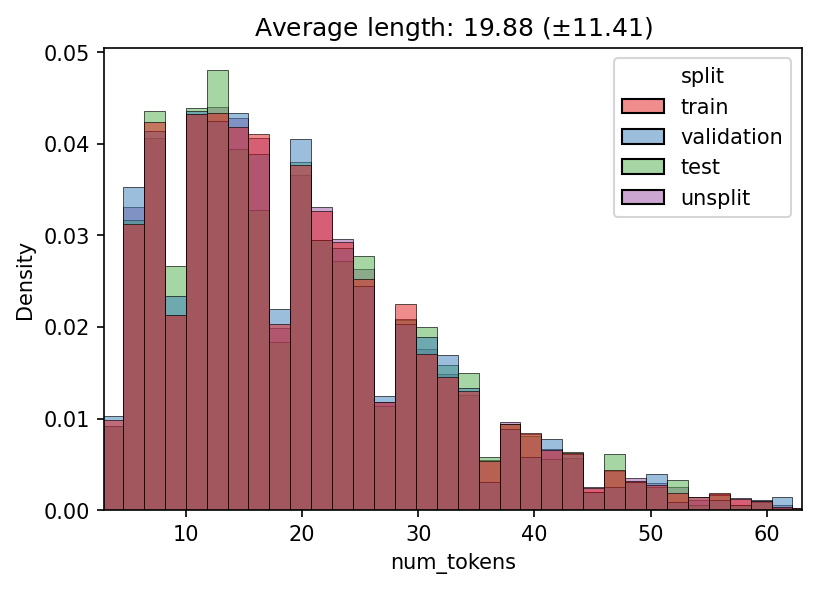

In [50]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=150)
sns.histplot(data=df_all, x='num_tokens', hue='split', palette="Set1", alpha=.5,
             stat="density", common_norm=False,
             edgecolor='k', shrink=1.0, bins=100, multiple="layer", ax=ax)
ax.set_title(
    f"Average length: {df_all['num_tokens'].mean():.2f} ($\pm${df_all['num_tokens'].std(ddof=1):.2f})"
)

# Set x-axis to show only the middle 99.8% of the data
lower_limit = df_all['num_tokens'].quantile(0.001)  #  0.1th percentile
upper_limit = df_all['num_tokens'].quantile(0.999)  # 99.9th percentile
ax.set_xlim(lower_limit, upper_limit)

plt.show(fig)

# 3. Compute Embeddings
- Model: `text-embedding-3-small`

In [19]:
import asyncio

from langchain_openai import OpenAIEmbeddings
from typing import List


async def batch_embed_documents(texts: List[str], batch_size: int = 10):
    
    # Initialize the embeddings class
    embedder = OpenAIEmbeddings(model='text-embedding-3-small',
                                max_retries=5,
                                request_timeout=120.,)

    # Create batches of texts
    batches = [texts[i:i + batch_size] for i in range(0, len(texts), batch_size)]
    print(f">> Split {len(texts)} documents into {len(batches)} batches")
    
    embeddings = []
    
    # Process each batch
    for i, batch in enumerate(batches):
        print(f">> Processing batch {i+1:>4,}/{len(batches):>4,} ({len(batch)} documents)")
        
        # Get embeddings for the current batch
        batch_embeddings = await embedder.aembed_documents(batch)
        embeddings.extend(batch_embeddings)
        
        print(f">>  Completed batch {i+1:>4,}/{len(batches):>4,}")
        
        # Optional: Add a delay between batches to avoid rate limits
        if i < len(batches) - 1:
            await asyncio.sleep(0.5)  # 500ms delay between batches
    
    print(f">> Generated {len(embeddings):,} embeddings in total")

    return np.array(embeddings)


Train Data

In [12]:
X_train = await batch_embed_documents(df_train['text'], batch_size=100)

>> Split 16000 documents into 160 batches
>> Processing batch    1/ 160 (100 documents)
>>  Completed batch    1/ 160
>> Processing batch    2/ 160 (100 documents)
>>  Completed batch    2/ 160
>> Processing batch    3/ 160 (100 documents)
>>  Completed batch    3/ 160
>> Processing batch    4/ 160 (100 documents)
>>  Completed batch    4/ 160
>> Processing batch    5/ 160 (100 documents)
>>  Completed batch    5/ 160
>> Processing batch    6/ 160 (100 documents)
>>  Completed batch    6/ 160
>> Processing batch    7/ 160 (100 documents)
>>  Completed batch    7/ 160
>> Processing batch    8/ 160 (100 documents)
>>  Completed batch    8/ 160
>> Processing batch    9/ 160 (100 documents)
>>  Completed batch    9/ 160
>> Processing batch   10/ 160 (100 documents)
>>  Completed batch   10/ 160
>> Processing batch   11/ 160 (100 documents)
>>  Completed batch   11/ 160
>> Processing batch   12/ 160 (100 documents)
>>  Completed batch   12/ 160
>> Processing batch   13/ 160 (100 documents)


In [13]:
print(X_train.shape)

(16000, 1536)


In [24]:
from pathlib import Path

root_dir = Path("../../").resolve()
print("Project directory:", root_dir)

Project directory: /Users/hgkahng/Workspaces/soft-prompt


In [26]:
model = "openai/text-embedding-3-small"
emb_save_dir = root_dir / f"data/emotion/embeddings/{model}"
os.makedirs(emb_save_dir, exist_ok=True)
print("Embeddings will be saved to:", emb_save_dir)

Embeddings will be saved to: /Users/hgkahng/Workspaces/soft-prompt/data/emotion/embeddings/openai/text-embedding-3-small


In [36]:
np.save(emb_save_dir / "train.features.npy", X_train)

In [37]:
y_train = df_train['label'].values
np.save(emb_save_dir / "train.labels.npy", y_train)

Validation Data

In [45]:
X_val = await batch_embed_documents(df_val['text'], batch_size=100)

>> Split 2000 documents into 20 batches
>> Processing batch    1/  20 (100 documents)
>>  Completed batch    1/  20
>> Processing batch    2/  20 (100 documents)
>>  Completed batch    2/  20
>> Processing batch    3/  20 (100 documents)
>>  Completed batch    3/  20
>> Processing batch    4/  20 (100 documents)
>>  Completed batch    4/  20
>> Processing batch    5/  20 (100 documents)
>>  Completed batch    5/  20
>> Processing batch    6/  20 (100 documents)
>>  Completed batch    6/  20
>> Processing batch    7/  20 (100 documents)
>>  Completed batch    7/  20
>> Processing batch    8/  20 (100 documents)
>>  Completed batch    8/  20
>> Processing batch    9/  20 (100 documents)
>>  Completed batch    9/  20
>> Processing batch   10/  20 (100 documents)
>>  Completed batch   10/  20
>> Processing batch   11/  20 (100 documents)
>>  Completed batch   11/  20
>> Processing batch   12/  20 (100 documents)
>>  Completed batch   12/  20
>> Processing batch   13/  20 (100 documents)
>>

In [46]:
X_val.shape

(2000, 1536)

In [47]:
np.save(emb_save_dir / "validation.features.npy", X_val)

In [48]:
y_val = df_val['label'].values
np.save(emb_save_dir / "validation.labels.npy", y_val)

Test Data

In [15]:
X_test = await batch_embed_documents(df_test['text'], batch_size=100)

>> Split 2000 documents into 20 batches
>> Processing batch    1/  20 (100 documents)
>>  Completed batch    1/  20
>> Processing batch    2/  20 (100 documents)
>>  Completed batch    2/  20
>> Processing batch    3/  20 (100 documents)
>>  Completed batch    3/  20
>> Processing batch    4/  20 (100 documents)
>>  Completed batch    4/  20
>> Processing batch    5/  20 (100 documents)
>>  Completed batch    5/  20
>> Processing batch    6/  20 (100 documents)
>>  Completed batch    6/  20
>> Processing batch    7/  20 (100 documents)
>>  Completed batch    7/  20
>> Processing batch    8/  20 (100 documents)
>>  Completed batch    8/  20
>> Processing batch    9/  20 (100 documents)
>>  Completed batch    9/  20
>> Processing batch   10/  20 (100 documents)
>>  Completed batch   10/  20
>> Processing batch   11/  20 (100 documents)
>>  Completed batch   11/  20
>> Processing batch   12/  20 (100 documents)
>>  Completed batch   12/  20
>> Processing batch   13/  20 (100 documents)
>>

In [16]:
print(X_test.shape)

(2000, 1536)


In [38]:
np.save(emb_save_dir / "test.features.npy", X_test)

In [39]:
y_test = df_test['label'].values
np.save(emb_save_dir / "test.labels.npy", y_test)

Unsplit Data

In [20]:
X_unsplit = await batch_embed_documents(df_unsplit['text'], batch_size=100)

>> Split 416809 documents into 4169 batches
>> Processing batch    1/4,169 (100 documents)
>>  Completed batch    1/4,169
>> Processing batch    2/4,169 (100 documents)
>>  Completed batch    2/4,169
>> Processing batch    3/4,169 (100 documents)
>>  Completed batch    3/4,169
>> Processing batch    4/4,169 (100 documents)
>>  Completed batch    4/4,169
>> Processing batch    5/4,169 (100 documents)
>>  Completed batch    5/4,169
>> Processing batch    6/4,169 (100 documents)
>>  Completed batch    6/4,169
>> Processing batch    7/4,169 (100 documents)
>>  Completed batch    7/4,169
>> Processing batch    8/4,169 (100 documents)
>>  Completed batch    8/4,169
>> Processing batch    9/4,169 (100 documents)
>>  Completed batch    9/4,169
>> Processing batch   10/4,169 (100 documents)
>>  Completed batch   10/4,169
>> Processing batch   11/4,169 (100 documents)
>>  Completed batch   11/4,169
>> Processing batch   12/4,169 (100 documents)
>>  Completed batch   12/4,169
>> Processing batch 

In [21]:
print(X_unsplit.shape)

(416809, 1536)


In [27]:
np.save(emb_save_dir / "unsplit.features.npy", X_unsplit)

In [28]:
y_unsplit = df_unsplit['label'].values
np.save(emb_save_dir / "unsplit.labels.npy", y_unsplit)

In [ ]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import f1_score

def evaluate_lg(X_train: np.ndarray,
                y_train: np.ndarray,
                X_test: np.ndarray,
                y_test: np.ndarray,
                subsample_size: int = 1000,
                bootstrap: bool = True,  # sampling with replacement
                n_trials: int = 50) -> dict[str, tuple[float, float]]:

    assert X_train.shape[0] == len(y_train)

    train_acc_array = np.empty(n_trials)
    test_acc_array = np.empty_like(train_acc_array)
    train_f1_array = np.empty(n_trials)
    test_f1_array = np.empty_like(train_f1_array)
    
    original_idx = np.arange(X_train.shape[0])  # [0, 1, ..., len(X_train)]

    for i in range(n_trials):
        
        # get indices to use for training
        rng = np.random.default_rng(42+i)
        if bootstrap:
            use_idx = rng.choice(original_idx, size=subsample_size, replace=True)
        else:
            shuffled_idx = rng.permutation(original_idx)
            use_idx = shuffled_idx[:subsample_size]

        # fit model
        lg = LogisticRegressionCV(Cs=10, cv=5, penalty='l2',
                                  solver='lbfgs', max_iter=1000, n_jobs=8,
                                  random_state=42+i)
        lg.fit(X_train[use_idx], y_train[use_idx]);

        # evaluate (simple accuracy)
        train_acc_array[i] = lg.score(X_train[use_idx], y_train[use_idx])
        test_acc_array[i] = lg.score(X_test, y_test)

        # evaluate (f1)
        train_f1_array[i] = \
            f1_score(y_train[use_idx], lg.predict(X_train[use_idx]), average='macro')
        test_f1_array[i] = \
            f1_score(y_test, lg.predict(X_test), average='macro')

    return {
        'train_accuracy': (train_acc_array.mean(), train_acc_array.std(ddof=1)),
        'test_accuracy': (test_acc_array.mean(), test_acc_array.std(ddof=1)),
        'train_f1': (train_f1_array.mean(), train_f1_array.std(ddof=1)),
        'test_f1': (test_f1_array.mean(), test_f1_array.std(ddof=1)),
    }

In [26]:
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [27]:
size_to_acc = {}


# (1.00, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 1.00)
subsample_sizes = [
    int(len(X_train) * r) for r in (0.25, 0.5, 1.0)
]
for i, subsample_size in enumerate(subsample_sizes):

    print(f">> Sample size: {subsample_size:>6,}")

    eval_result = evaluate_lg(
        X_train, y_train, X_test, y_test,
        subsample_size=subsample_size,
        bootstrap=True,
        n_trials=5,
    )

    train_acc, test_acc = \
        eval_result['train_accuracy'], eval_result['test_accuracy']
    train_f1, test_f1 = \
        eval_result['train_f1'], eval_result['test_f1']

    size_to_acc[subsample_size] = eval_result

    print("\t Train acc = {:.4f} ({:.4f})".format(*train_acc))
    print("\t  Test acc = {:.4f} ({:.4f})".format(*test_acc))
    print("\t Train  f1 = {:.4f} ({:.4f})".format(*train_f1))
    print("\t  Test  f1 = {:.4f} ({:.4f})".format(*test_f1))

>> Sample size:  4,000
	 Train acc = 0.9711 (0.0023)
	  Test acc = 0.7209 (0.0090)
	 Train  f1 = 0.9710 (0.0017)
	  Test  f1 = 0.6420 (0.0092)
>> Sample size:  8,000
	 Train acc = 0.9462 (0.0060)
	  Test acc = 0.7508 (0.0103)
	 Train  f1 = 0.9429 (0.0068)
	  Test  f1 = 0.6790 (0.0120)
>> Sample size: 16,000
	 Train acc = 0.9570 (0.0256)
	  Test acc = 0.7431 (0.0116)
	 Train  f1 = 0.9546 (0.0296)
	  Test  f1 = 0.6687 (0.0088)
